In [2]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
spark = SparkSession.builder.appName("EDA").getOrCreate()

In [5]:
data_folder = "./sales_forecasting_data"
df = spark.read.csv(f"{data_folder}/cleaned_data", header=True, inferSchema=True)

So for the EDA, I started by splitting the data. The EDA won't be performed on the test data because it might overfit to the data.

In [6]:
train_df = df.filter(F.col("date") < '2017-01-01')
test_df = df.filter(F.col("date") >= '2017-01-01')

Since this is a time-series forecasting, I split the train/test data by time. Data starting 2017 will be used as the test data

In [56]:
train_df.count(), test_df.count()

(103726147, 24244110)

In [57]:
train_df.printSchema()

root
 |-- date: date (nullable = true)
 |-- store_nbr: integer (nullable = true)
 |-- item_nbr: integer (nullable = true)
 |-- id: integer (nullable = true)
 |-- unit_sales: double (nullable = true)
 |-- onpromotion: boolean (nullable = true)
 |-- family: string (nullable = true)
 |-- class: integer (nullable = true)
 |-- perishable: integer (nullable = true)
 |-- city: string (nullable = true)
 |-- state: string (nullable = true)
 |-- type: string (nullable = true)
 |-- cluster: integer (nullable = true)
 |-- transactions: integer (nullable = true)
 |-- dcoilwtico: double (nullable = true)
 |-- holiday: boolean (nullable = true)



First, I look at the mean, standard deviation, and min, max of the unit sales data.

In [6]:
train_df.select("unit_sales").describe().show()

+-------+------------------+
|summary|        unit_sales|
+-------+------------------+
|  count|         103726147|
|   mean| 8.661906132583894|
| stddev|24.130125570841827|
|    min|          -15372.0|
|    max|           89440.0|
+-------+------------------+



Seems like there are some extreme outliers in the data. I'm not sure if this is an error in the dataset or not. But let's proceed with this data for now since I'm not sure. (I looked at some itmes and it seems like some of them had an average unit sales of 32,000 so this might not be an error in data)

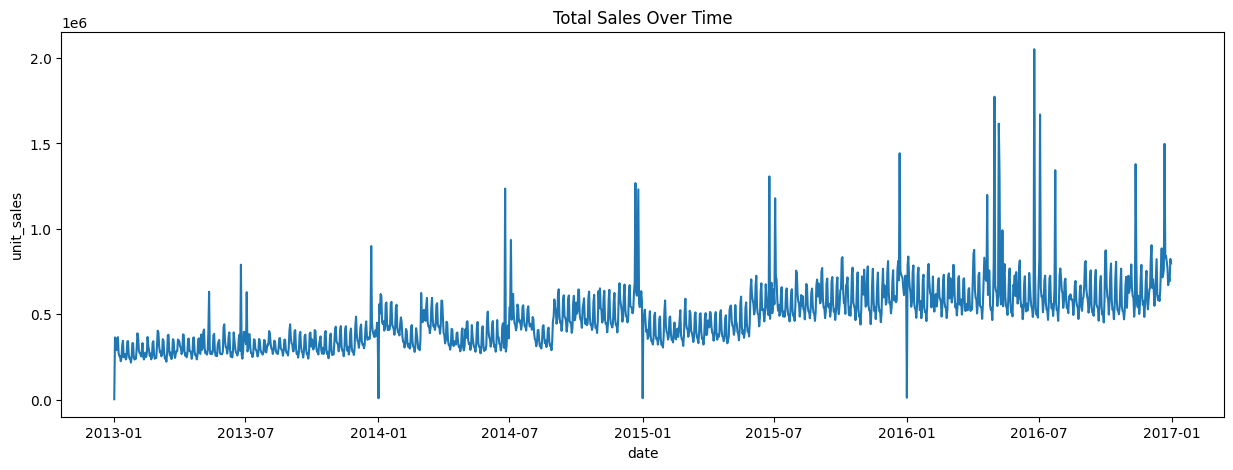

In [15]:
daily_sales = train_df.groupBy("date").agg(F.sum("unit_sales").alias("unit_sales"))

daily_sales_pd = daily_sales.toPandas().sort_values("date")

plt.figure(figsize=(15, 5))
sns.lineplot(data=daily_sales_pd, x="date", y="unit_sales")
plt.title("Total Sales Over Time")
plt.show()

Seems like in over the years, the total sales have increased. Now, I will look at how the earthquake on April 16, 2016 affected the sales.

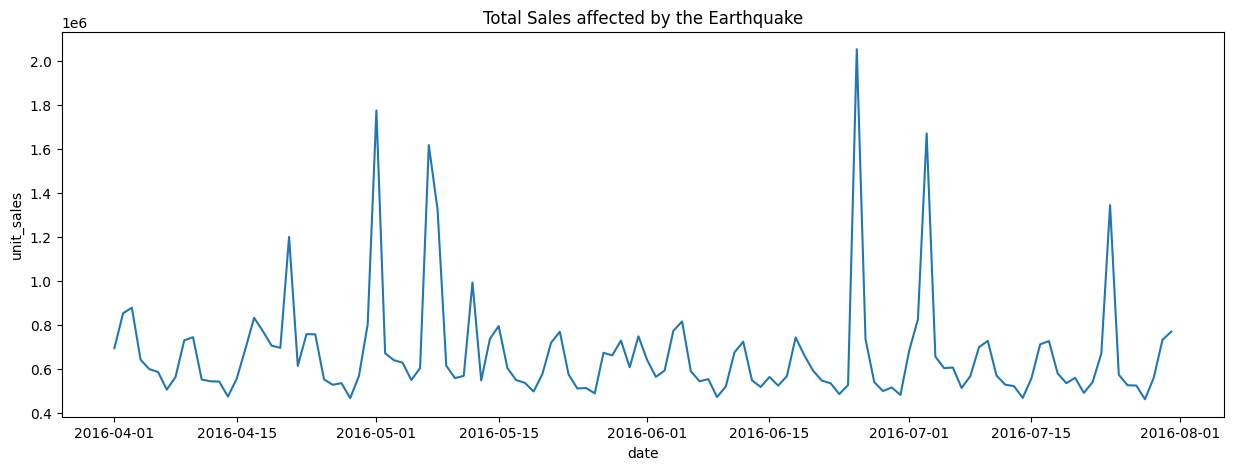

In [16]:
filtered_df = train_df.filter(
    (F.col("date") >= "2016-04-01") & (F.col("date") <= "2016-07-31")
)

daily_sales = filtered_df.groupBy("date").agg(F.sum("unit_sales").alias("unit_sales"))

daily_sales_pd = daily_sales.toPandas().sort_values("date")

plt.figure(figsize=(15, 5))
sns.lineplot(data=daily_sales_pd, x="date", y="unit_sales")
plt.title("Total Sales affected by the Earthquake")
plt.show()

The earthquake on April 16, 2016 might have caused a spike in sales, but spikes like this can be found throughout the data (like in July 2016 from the graph), so it's hard to say it's because of the earthquake.

I will now plot the total sales vs the oil price, to see if there is any correlation.

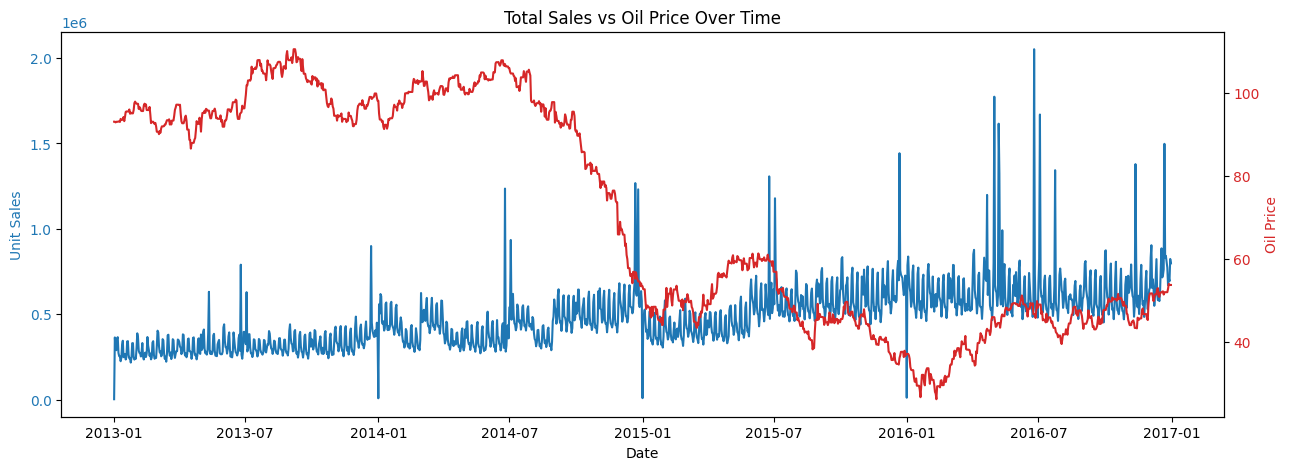

In [17]:
daily_data = train_df.groupBy("date").agg(
    F.sum("unit_sales").alias("unit_sales"),
    F.avg("dcoilwtico").alias("dcoilwtico")
)

daily_data_pd = daily_data.toPandas()

fig, ax1 = plt.subplots(figsize=(15,5))

color = 'tab:blue'
ax1.set_xlabel('Date')
ax1.set_ylabel('Unit Sales', color=color)
sns.lineplot(data=daily_data_pd, x='date', y='unit_sales', ax=ax1, color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Oil Price', color=color)
sns.lineplot(data=daily_data_pd, x='date', y='dcoilwtico', ax=ax2, color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title('Total Sales vs Oil Price Over Time')
plt.show()

The oil price declined heavily since mid-2014, this might explain why the total sales increased over time. But from the graph, it's hard to see the correlation.

Next, I will find the effect of promotion flags on the sales

In [7]:
train_df.groupBy("onpromotion").agg(F.mean("unit_sales").alias("avg_unit_sales")).show()

+-----------+------------------+
|onpromotion|    avg_unit_sales|
+-----------+------------------+
|       true|13.315654236110555|
|      false| 8.416780389288226|
+-----------+------------------+



Looks like the promotion flag has a significant effect on sales. This makes a lot of sense as consumer are much more likely to purchase any product on sales. This is a very meaningful feature that might need to be further explored. Let's move onto the impact of holiday on sales.

In [8]:
train_df.groupBy("holiday").agg(F.mean("unit_sales").alias("avg_unit_sales")).show()

+-------+-----------------+
|holiday|   avg_unit_sales|
+-------+-----------------+
|   true|8.792764674324376|
|  false|8.648065366088552|
+-------+-----------------+



The average sales on holiday is a little bit higher, but this is very insignificant (only a 1.7 percent increase). What about perishability?

In [9]:
# Find effect of perishability on sales
train_df.groupBy("perishable").agg(F.mean("unit_sales").alias("avg_unit_sales")).show()

+----------+------------------+
|perishable|    avg_unit_sales|
+----------+------------------+
|         1|10.864522152435114|
|         0| 7.920270005323571|
+----------+------------------+



25/09/03 00:38:49 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 922992 ms exceeds timeout 120000 ms
25/09/03 00:38:49 WARN SparkContext: Killing executors is not supported by current scheduler.
25/09/03 00:55:43 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:53)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:342)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:132)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$

Perishable item have a way higher average sales, which makes a lot of sense.

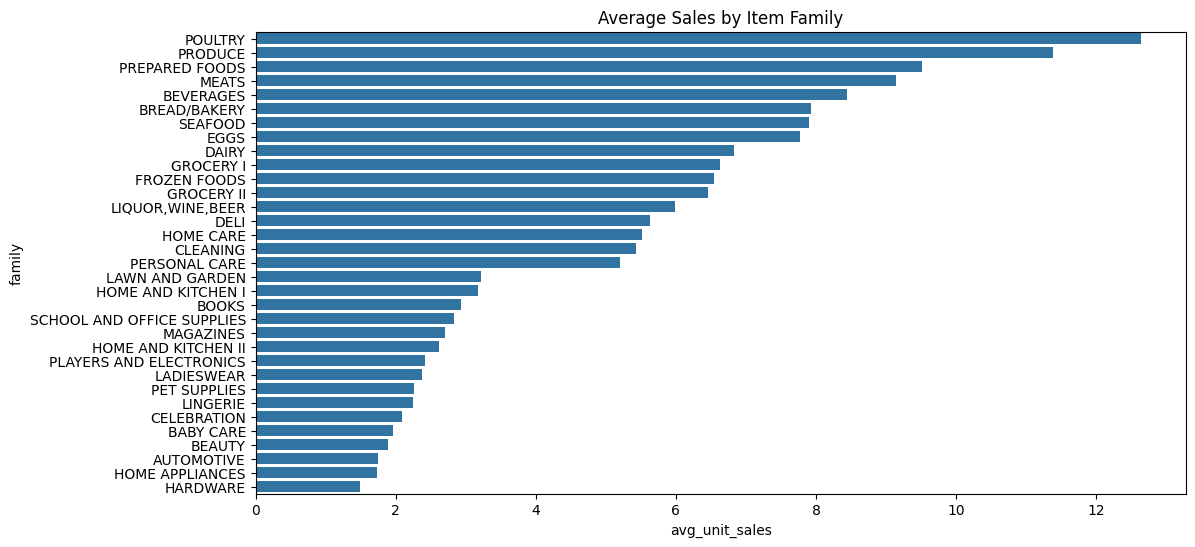

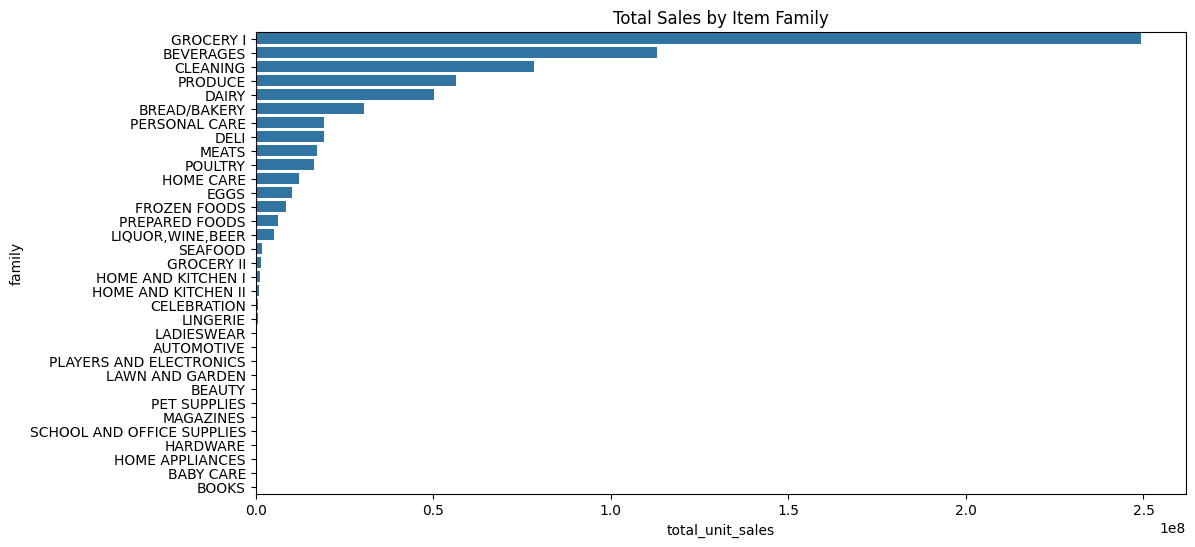

In [21]:
avg_sale_df = train_df.groupBy("family") \
           .agg(F.mean("unit_sales").alias("avg_unit_sales")) \
           .orderBy(F.desc("avg_unit_sales")) \
           .toPandas()

plt.figure(figsize=(12, 6))
sns.barplot(data=avg_sale_df, x='avg_unit_sales', y='family')
plt.title("Average Sales by Item Family")
plt.show()

total_sale_df = train_df.groupBy("family") \
                 .agg(F.sum("unit_sales").alias("total_unit_sales")) \
                 .orderBy(F.desc("total_unit_sales"))

family_sales_pd = total_sale_df.toPandas()

plt.figure(figsize=(12,6))
sns.barplot(data=family_sales_pd, x="total_unit_sales", y="family")
plt.title("Total Sales by Item Family")
plt.show()

Looks like poultry has the highest average sale, while grocery items and breverages have the highest total sales.

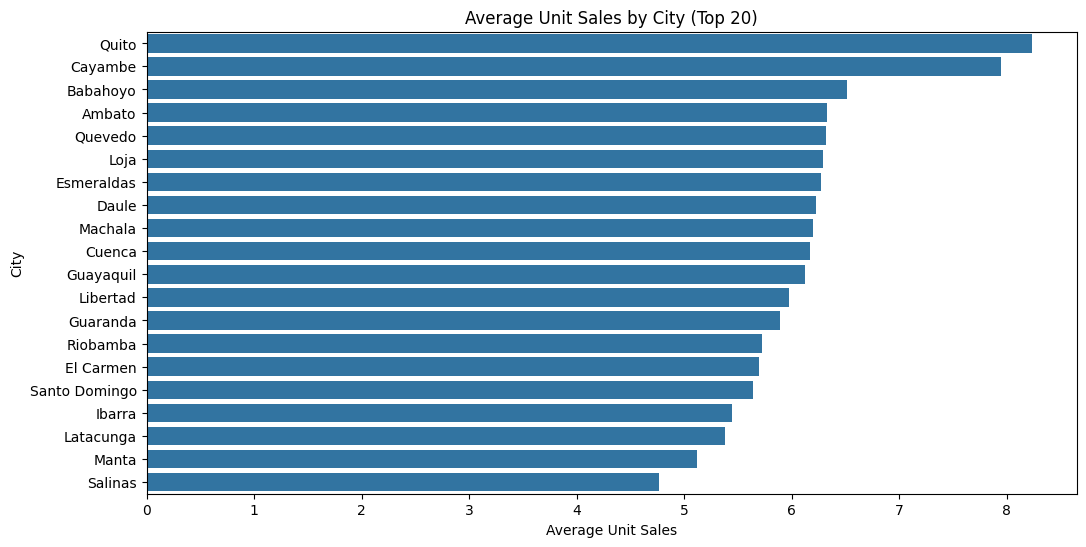

In [22]:
city_sales = train_df.groupBy("city") \
               .agg(F.mean("unit_sales").alias("avg_unit_sales")) \
               .orderBy(F.desc("avg_unit_sales")) \
               .limit(20)

city_sales_pd = city_sales.toPandas()

plt.figure(figsize=(12,6))
sns.barplot(x=city_sales_pd["avg_unit_sales"], y=city_sales_pd["city"])
plt.title("Average Unit Sales by City (Top 20)")
plt.xlabel("Average Unit Sales")
plt.ylabel("City")
plt.show()

Average sales in Cayambe and Quito are higher compared to other cities, and it looks like the cities would be a useful feature because the average sales varied a lot.

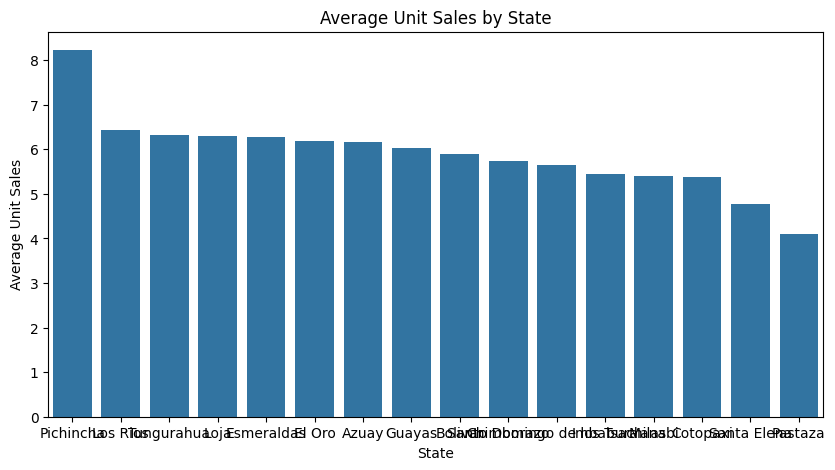

In [ ]:
state_sales = train_df.groupBy("state") \
                .agg(F.mean("unit_sales").alias("avg_unit_sales")) \
                .orderBy(F.desc("avg_unit_sales"))

state_sales_pd = state_sales.toPandas()

plt.figure(figsize=(10,5))
sns.barplot(x=state_sales_pd["state"], y=state_sales_pd["avg_unit_sales"])
plt.title("Average Unit Sales by State")
plt.xlabel("State")
plt.ylabel("Average Unit Sales")
plt.show()

Similarly, the state also matters.

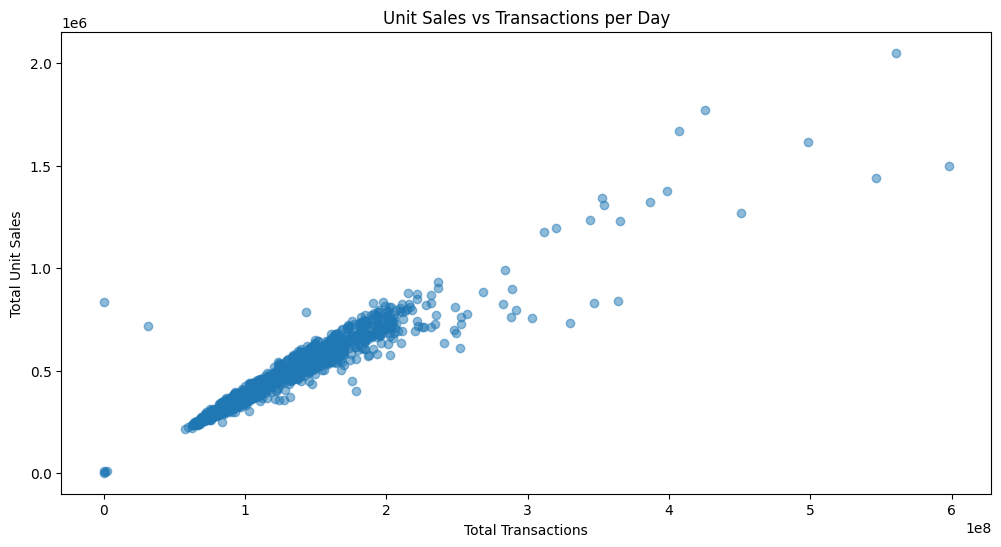

In [24]:
agg_df = train_df.groupBy("date").agg(
    F.sum("unit_sales").alias("total_sales"),
    F.sum("transactions").alias("total_transactions")
).orderBy("date")

agg_pd = agg_df.toPandas()

plt.figure(figsize=(12,6))
plt.scatter(agg_pd["total_transactions"], agg_pd["total_sales"], alpha=0.5)
plt.xlabel("Total Transactions")
plt.ylabel("Total Unit Sales")
plt.title("Unit Sales vs Transactions per Day")
plt.show()

The transactions and unit sales seems to have a strong correlation.

I will explore the impact of day and month next.

In [ ]:
# Extract day of week and month
train_df = train_df.withColumn("day_of_week", F.date_format(F.col("date"), "EEEE"))
train_df = train_df.withColumn("month", F.date_format(F.col("date"), "MMMM"))

# Convert name to number
train_df = train_df.withColumn("day_of_week", F.dayofweek(F.col("date"))) # 1=Sunday, 2=Monday, ..., 7=Saturday
train_df = train_df.withColumn("month", F.month(F.col("date"))) 

train_df.show()

+----------+---------+--------+--------+----------+-----------+---------+-----+----------+-----+---------+----+-------+------------+----------+-------+-----------+-----+
|      date|store_nbr|item_nbr|      id|unit_sales|onpromotion|   family|class|perishable| city|    state|type|cluster|transactions|dcoilwtico|holiday|day_of_week|month|
+----------+---------+--------+--------+----------+-----------+---------+-----+----------+-----+---------+----+-------+------------+----------+-------+-----------+-----+
|2016-12-04|       48| 1935388|98928753|       2.0|      false|   BEAUTY| 4255|         0|Quito|Pichincha|   A|     14|        4427|      51.7|  false|          1|   12|
|2016-12-04|       48| 1936589|98928754|       3.0|      false|GROCERY I| 1034|         0|Quito|Pichincha|   A|     14|        4427|      51.7|  false|          1|   12|
|2016-12-04|       48| 1936931|98928755|      22.0|       true|BEVERAGES| 1124|         0|Quito|Pichincha|   A|     14|        4427|      51.7|  false

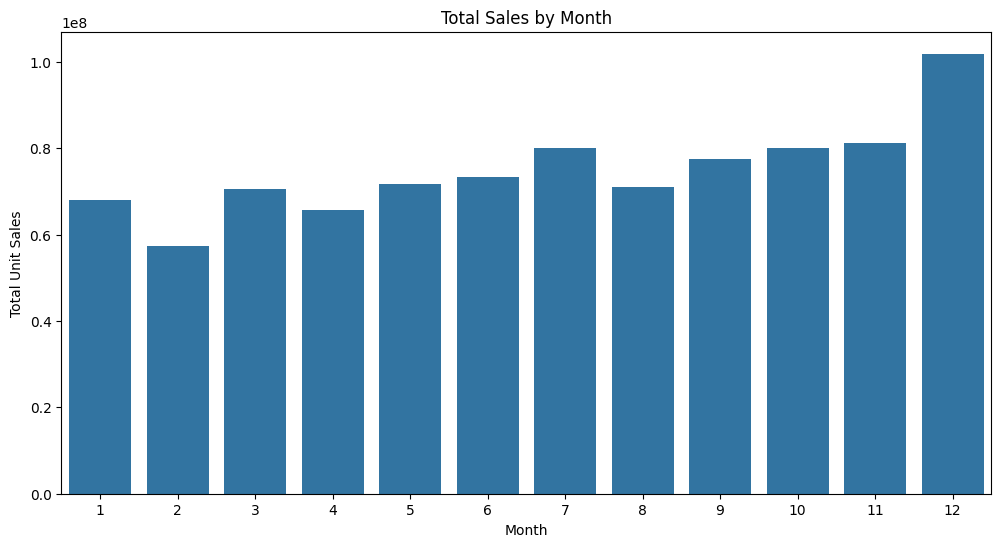

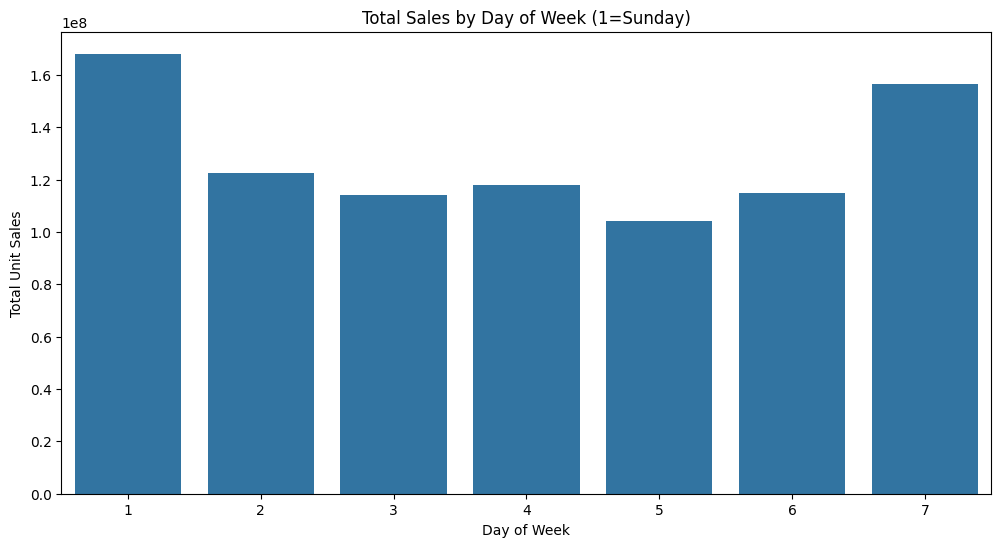

In [69]:
sales_by_month = train_df.groupBy("month") \
                         .agg(F.sum("unit_sales").alias("total_sales")) \
                         .orderBy("month") \
                         .toPandas()

plt.figure(figsize=(12,6))
sns.barplot(data=sales_by_month, x="month", y="total_sales")
plt.title("Total Sales by Month")
plt.xlabel("Month")
plt.ylabel("Total Unit Sales")
plt.show()

sales_by_dow = train_df.groupBy("day_of_week") \
                       .agg(F.sum("unit_sales").alias("total_sales")) \
                       .orderBy("day_of_week") \
                       .toPandas()

plt.figure(figsize=(12,6))
sns.barplot(data=sales_by_dow, x="day_of_week", y="total_sales")
plt.title("Total Sales by Day of Week (1=Sunday)")
plt.xlabel("Day of Week")
plt.ylabel("Total Unit Sales")
plt.show()

From this, we can see that on the weekend (Saturday(7) and Sunday(1)), the sales are higher, whereas the sales are highest in december when we compare month.

Wages in the public sector are paid every two weeks on the 15 th and on the last day of the month. Supermarket sales could be affected by this.

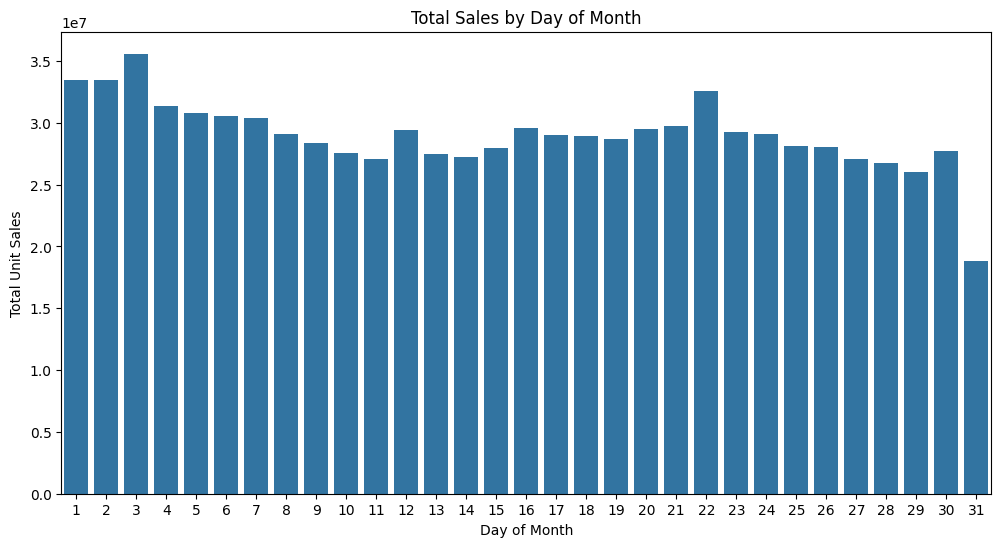

In [70]:
train_df = train_df.withColumn("day_of_month", F.dayofmonth(F.col("date")))

sales_by_dow = train_df.groupBy("day_of_month") \
                       .agg(F.sum("unit_sales").alias("total_sales")) \
                       .orderBy("day_of_month") \
                       .toPandas()

plt.figure(figsize=(12,6))
sns.barplot(data=sales_by_dow, x="day_of_month", y="total_sales")
plt.title("Total Sales by Day of Month")
plt.xlabel("Day of Month")
plt.ylabel("Total Unit Sales")
plt.show()

The wage payday doesn't seem to impact the sales much, but the total sales are higher during at the start of each month, so this would be a great feature to have.

Since earlier we found that promotion had a significant effect on sales, and because lags and rolling averages are generally a good feature for time series prediction, I going to look at the number of promotion in previous timeframe.

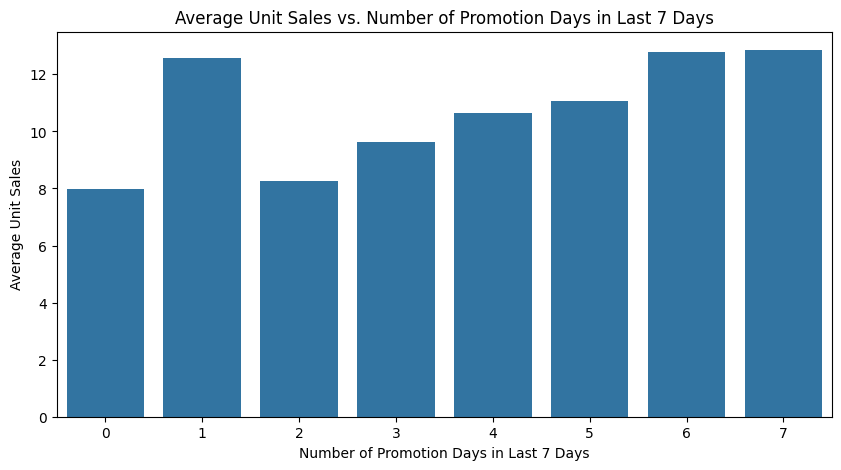

In [71]:
window = Window.partitionBy("store_nbr", "item_nbr").orderBy("date").rowsBetween(-6, 0)
promo_7_df = train_df.withColumn("promo_7_days", F.sum(F.col("onpromotion").cast("int")).over(window))

agg_df = promo_7_df.groupBy("promo_7_days").agg(
    F.mean("unit_sales").alias("avg_unit_sales")
).orderBy("promo_7_days")

agg_pd = agg_df.toPandas()

plt.figure(figsize=(10,5))
sns.barplot(x="promo_7_days", y="avg_unit_sales", data=agg_pd)
plt.title("Average Unit Sales vs. Number of Promotion Days in Last 7 Days")
plt.xlabel("Number of Promotion Days in Last 7 Days")
plt.ylabel("Average Unit Sales")
plt.show()


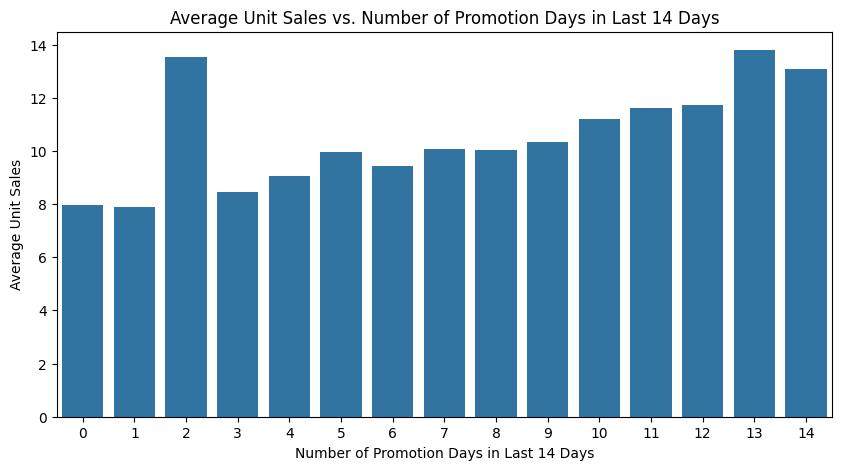

In [72]:
window = Window.partitionBy("store_nbr", "item_nbr").orderBy("date").rowsBetween(-13, 0)
promo_14_df = train_df.withColumn("promo_14_days", F.sum(F.col("onpromotion").cast("int")).over(window))

agg_df = promo_14_df.groupBy("promo_14_days").agg(
    F.mean("unit_sales").alias("avg_unit_sales")
).orderBy("promo_14_days")

agg_pd = agg_df.toPandas()

plt.figure(figsize=(10,5))
sns.barplot(x="promo_14_days", y="avg_unit_sales", data=agg_pd)
plt.title("Average Unit Sales vs. Number of Promotion Days in Last 14 Days")
plt.xlabel("Number of Promotion Days in Last 14 Days")
plt.ylabel("Average Unit Sales")
plt.show()


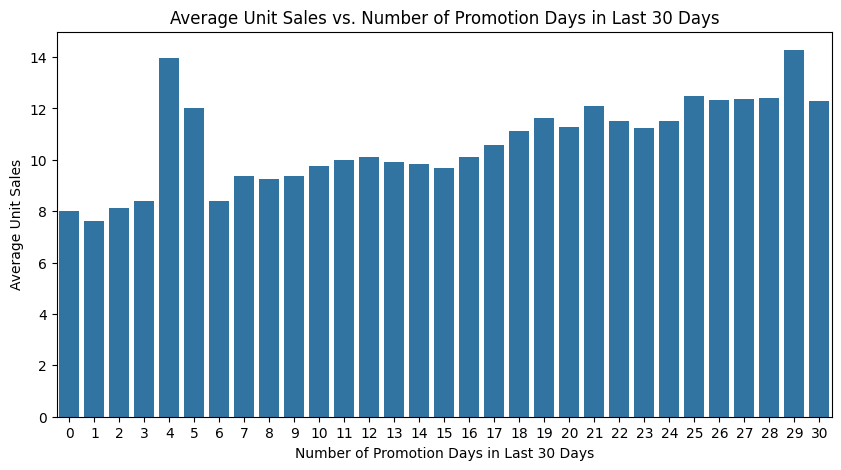

In [73]:
window = Window.partitionBy("store_nbr", "item_nbr").orderBy("date").rowsBetween(-29, 0)
promo_30_df = train_df.withColumn("promo_30_days", F.sum(F.col("onpromotion").cast("int")).over(window))

agg_df = promo_30_df.groupBy("promo_30_days").agg(
    F.mean("unit_sales").alias("avg_unit_sales")
).orderBy("promo_30_days")

agg_pd = agg_df.toPandas()

plt.figure(figsize=(10,5))
sns.barplot(x="promo_30_days", y="avg_unit_sales", data=agg_pd)
plt.title("Average Unit Sales vs. Number of Promotion Days in Last 30 Days")
plt.xlabel("Number of Promotion Days in Last 30 Days")
plt.ylabel("Average Unit Sales")
plt.show()

From this, we can see a trend that the more promotion in the last X days timeframe, the higher the average sales (except for a few outlier).

The reason for choosing 7,14,30 days is because it is a 1 week, 2 week, and 1 month timeframe which seems relevant

Promotion counts in 7 days vs 30 days would not be redundant, because the 7 days promotion count would focus more on recent promotion, which logically would be more impactful.

In [25]:
spark.stop()